# Desafio Titanic Random Forest 

## Imagen para analizar 

https://hedbergmaps.com/cdn/shop/products/titanic-reference-map-back_51595c99-0e06-40f4-af1e-430a58aecca2.jpg?v=1595688039
https://multitools.newscdn.com.au/multitools/slider/content/1744165346586/NED-13514-Titanic-damage_gdVTgCl_Qn.jpg
https://scx1.b-cdn.net/csz/news/800a/2012/grapplingwit.jpg


## Librerias

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import re

### graficos que se vean profesionales

In [2]:
# Configuración visual para que los gráficos se vean profesionales
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

### Carga de archivos

In [3]:
file_names = ['train', 'test', 'gender_submission']
dfs = {} 

try:
    base_path = 'data-titanic/'
    
    for name in file_names:
        full_path = f"{base_path}{name}.csv"
        dfs[name] = pd.read_csv(full_path)
        
        print(f"✅ Datos '{name}' cargados correctamente.")
        print(f"   └── Dimensiones: {dfs[name].shape}")

    train = dfs['train']
    test = dfs['test']
    submission = dfs['gender_submission']

except FileNotFoundError:
    print(f"❌ Error crítico: No se encontró el archivo en la ruta: {full_path}")
    print("   Verifica que el archivo exista y la ruta sea correcta.")
except Exception as e:
    print(f"❌ Ocurrió un error inesperado: {e}")

✅ Datos 'train' cargados correctamente.
   └── Dimensiones: (891, 12)
✅ Datos 'test' cargados correctamente.
   └── Dimensiones: (418, 11)
✅ Datos 'gender_submission' cargados correctamente.
   └── Dimensiones: (418, 2)


## EDA 

### Analisis preliminar de Variables 

#### analisis de las estructuras del los datos 

In [4]:
# 1. Vistazo a la estructura física (Filas y Columnas de ejemplo)
print("--- 1. Muestra de los primeros 5 pasajeros ---")
display(train.head()) 

--- 1. Muestra de los primeros 5 pasajeros ---


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
# 2. Información Técnica (Tipos de datos y Nulos)
print("\n--- 2. Información Técnica (Tipos y Nulos) ---")
train.info()


--- 2. Información Técnica (Tipos y Nulos) ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


#### Variables del DataSet

|Variable|Definicion|Key|
|------|--------------------------|---|
|``pclass``|SES: status socio-economic| 1st = Upper, 2nd = Middle, 3rd = Lower|
|``Age``|La edad es fraccionaria si es menor que 1. Si la edad es estimada, está en formato xx.5| |
|``SibSP`` | # de hermanos/conygues a bordo del Titanic.  El conjunto de datos define las relaciones familiares de esta manera... Hermano = hermano, hermana, hermanastro, hermanastra. Cónyuge = esposo, esposa (amantes y prometidos fueron ignorados)| |
|``parch`` |# de padres/hijos a bordo del titanic. El conjunto de datos define las relaciones familiares de esta manera... Padre = madre, padre Niño = hija, hijo, hijastra, hijastro Algunos niños viajaron solo con una niñera, por lo tanto, parch = 0 para ellos.| |
|``ticket``|numero del boleto| |
|``fare``|tarifa de pasajero | |
|``cabin``|numero de cabina| |
|``embarked``|pouerto de embarque|C = Cherbourg, Q = Queenstown, S = Southampton||

In [6]:
# 4. Resumen de Variables Categóricas (Para texto: Valores únicos, Frecuencia)
print("\n--- 4. Resumen Estadístico (Variables Categóricas/Texto) ---")
display(train.describe(include=['O']))


--- 4. Resumen Estadístico (Variables Categóricas/Texto) ---


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


--- Frecuencia de Pclass ---
Pclass
1    216
2    184
3    491
Name: count, dtype: int64

--- Frecuencia de SibSp ---
SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

--- Frecuencia de Parch ---
Parch
0    678
1    118
2     80
3      5
4      4
5      5
6      1
Name: count, dtype: int64


/tmp/ipykernel_3513/2572503069.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Pclass', data=train, ax=axes[0], palette='viridis')
/tmp/ipykernel_3513/2572503069.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='SibSp', data=train, ax=axes[1], palette='viridis')
/tmp/ipykernel_3513/2572503069.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Parch', data=train, ax=axes[2], palette='viridis')


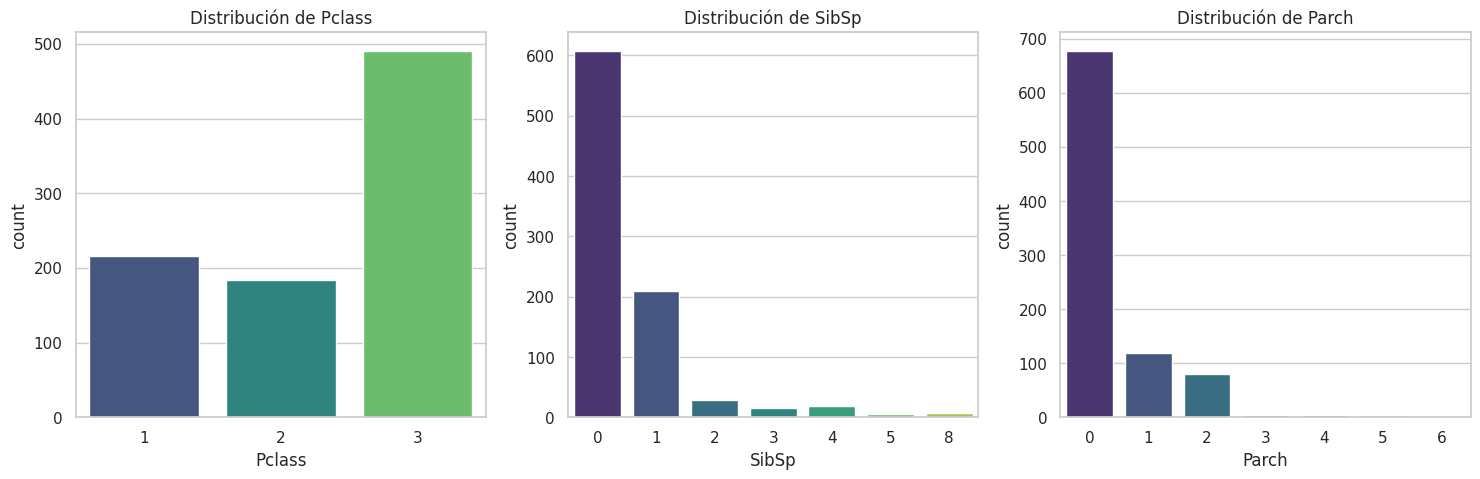

In [7]:
# Bloque de Análisis de Frecuencias

# 1. Pclass (Clase Social)
print("--- Frecuencia de Pclass ---")
# .sort_index() ordena por el valor de la clase (1, 2, 3) en lugar de por la cantidad
print(train['Pclass'].value_counts().sort_index())

# 2. SibSp (Hermanos/Cónyuges)
print("\n--- Frecuencia de SibSp ---")
print(train['SibSp'].value_counts().sort_index())

# 3. Parch (Padres/Hijos)
print("\n--- Frecuencia de Parch ---")
print(train['Parch'].value_counts().sort_index())

# --- BONUS: Visualización rápida ---
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(x='Pclass', data=train, ax=axes[0], palette='viridis')
axes[0].set_title('Distribución de Pclass')

sns.countplot(x='SibSp', data=train, ax=axes[1], palette='viridis')
axes[1].set_title('Distribución de SibSp')

sns.countplot(x='Parch', data=train, ax=axes[2], palette='viridis')
axes[2].set_title('Distribución de Parch')

plt.show()

#### Estadistica Descriptiva

In [8]:
# 3. Estadísticos Descriptivos (Para numéricas: Media, Desviación, Mín/Máx)
print("\n--- 3. Resumen Estadístico (Variables Numéricas) ---")
display(train.describe())


--- 3. Resumen Estadístico (Variables Numéricas) ---


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [9]:
# 5. La prueba de la verdad para tus dudas (Valores Únicos)
print("\n--- 5. Análisis de Valores Únicos para Clasificación ---")
print(f"Valores únicos en Pclass: {sorted(train['Pclass'].unique())}")
print(f"Valores únicos en SibSp:  {sorted(train['SibSp'].unique())}")
print(f"Valores únicos en Parch:  {sorted(train['Parch'].unique())}")
print(f"Ejemplo de un Ticket repetido: {train['Ticket'].mode()[0]}")


--- 5. Análisis de Valores Únicos para Clasificación ---
Valores únicos en Pclass: [np.int64(1), np.int64(2), np.int64(3)]
Valores únicos en SibSp:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(8)]
Valores únicos en Parch:  [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Ejemplo de un Ticket repetido: 1601


#### Conclusion sobre variables

**1. ``Pclass`` (Clase Socioeconómica)** 
- Se confirma que esta variable es Ordinal, no solo nominal. Existe una jerarquía clara donde el estatus social desciende desde la clase 1 a la 3 ($1 > 2 > 3$). Esta naturaleza ordinal es crítica porque sugiere una correlación monotónica con la supervivencia (a mayor estatus, mayor probabilidad de vivir). No podemos tratarla simplemente como categorías aisladas; el "orden" importa. 
- *Validación Estadística*: Para probar científicamente que la supervivencia no es aleatoria respecto a la clase, se aplicara una Prueba Chi-Cuadrado de Independencia ($\chi^2$). 
    - $H_0$ (Hipótesis Nula): La supervivencia es independiente de la clase social. 
    - $H_1$ (Hipótesis Alternativa): La clase social afecta significativamente la tasa de supervivencia.

**2. ``Ticket`` (Dinámicas de Grupo)**
- Se Detecto que hay tickets repetidos, lo que indica que varios pasajeros compartían el mismo boleto. Se procedera a refinar la interpretación de "sobrecupo". Un ticket compartido representa un Grupo Social (familias, amigos, sirvientes). 
- La hipótesis refinada es que el tamaño del grupo tiene un efecto no lineal: los grupos pequeños (2-4 personas) tienden a colaborar y aumentar su supervivencia, mientras que los grupos masivos (como familias de 8+ miembros en 3ra clase) sufren de "caos de coordinación", disminuyendo su probabilidad de sobrevivencia. Se Creara una nueva variable llamada ``TicketFrequency`` para capturar este fenómeno, en lugar de borrar la columna.

**3. ``Parch`` (Casos Especiales / Niñeras)**
- Se Observa niños (Age < 15) con Parch = 0 (sin padres registrados), lo cual es contraintuitivo. En Primera Clase, un niño sin padres registrados probablemente viaja con una niñera (cuyo ticket es distinto o tiene un apellido diferente). En cambio, en Tercera Clase, es más probable que sea un dato perdido o un huérfano real. 
- Se cruzara las variables Age, Parch y Pclass. Si se valida la hipótesis de la niñera, se podra imputar datos o crear una bandera de "Acompañado por Staff", lo cual es limpieza de datos avanzada.

**4. ``SibSp`` (Comportamiento Colectivo)**
- Se necesita determinar si tener hermanos/cónyuges (SibSp) aumenta la supervivencia mediante el apoyo mutuo.Feedback Técnico: La relación probablemente no es lineal. Tener 1 o 2 acompañantes ofrece apoyo moral y físico (positivo), pero tener 5+ genera dificultades logísticas para moverse y acceder a los botes (negativo).
- Validación Estadística: Dado que la variable SibSp no sigue una distribución normal (la gran mayoría de pasajeros tiene 0), una prueba T-Student daría errores. Se usara prueba no paramétrica como la U de Mann-Whitney o Kruskal-Wallis para comparar si la distribución de familiares difiere significativamente entre los sobrevivientes y los fallecidos.

**5. `Name` (Nombre)**
- El análisis preliminar de la variable Name revela la presencia de títulos honoríficos y nobiliarios (ej. Mr., Master, Countess). La estrategia consiste en extraer estos títulos mediante técnicas de procesamiento de texto para generar una nueva variable categórica llamada Title. Posteriormente, se realizara una prueba estadística para determinar si existe una diferencia significativa en la probabilidad de supervivencia asociada a cada título social.

## Analisis de la Variable `pClass`

### Prueba Chi-cuadrado de Independencia

**Prueba Chi-Cuadrado de Independencia $\chi^2$**
|$H_0$|$H_1$|
|-----|----|
|*La supervivencia es independiente de la clase social.*|*La clase social afecta significativamente la tasa de supervivencia.*|

In [10]:
# 1. Preparación de Datos (Tabla de Contingencia)
# Cruzamos Pclass (Filas) vs Survived (Columnas)
contingency_table = pd.crosstab(train['Pclass'], train['Survived'])

print("\n1. Tabla de Contingencia (Observados):")
print("   (Muestra cuántos murieron (0) y vivieron (1) por clase)")
display(contingency_table)

# 2. Porcentajes para mejor intuición
print("\n2. Probabilidad de Supervivencia por Clase:")
print((pd.crosstab(train['Pclass'], train['Survived'], normalize='index') * 100).round(0))

# 3. Prueba Chi-Cuadrado de Independencia
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_table)

print("\n3. Resultados de la Prueba Chi-Cuadrado:")
print(f"   - Estadístico Chi2: {chi2:.4f}")
print(f"   - P-Value: {p_value:.4e}")  # Notación científica para precisión
print(f"   - Grados de Libertad: {dof}")

# 4. Interpretación Automática
alpha = 0.05
print("\n--- CONCLUSIÓN ESTADÍSTICA ---")
if p_value < alpha:
    print(f"✅ P-value ({p_value:.4e}) < {alpha}. RECHAZAMOS la Hipótesis Nula.")
    print("   EXISTE una dependencia estadísticamente significativa entre la Clase Social y la Supervivencia.")
    print("   (La clase social influyó en quién vivía y quién moría).")
else:
    print(f"❌ P-value ({p_value:.4e}) > {alpha}. NO podemos rechazar la Hipótesis Nula.")
    print("   No hay evidencia suficiente para decir que la clase influyó.")


1. Tabla de Contingencia (Observados):
   (Muestra cuántos murieron (0) y vivieron (1) por clase)


Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119



2. Probabilidad de Supervivencia por Clase:
Survived     0     1
Pclass              
1         37.0  63.0
2         53.0  47.0
3         76.0  24.0

3. Resultados de la Prueba Chi-Cuadrado:
   - Estadístico Chi2: 102.8890
   - P-Value: 4.5493e-23
   - Grados de Libertad: 2

--- CONCLUSIÓN ESTADÍSTICA ---
✅ P-value (4.5493e-23) < 0.05. RECHAZAMOS la Hipótesis Nula.
   EXISTE una dependencia estadísticamente significativa entre la Clase Social y la Supervivencia.
   (La clase social influyó en quién vivía y quién moría).


## Analisis Variable `Title` a traves de `name` 

A partir de los registros del Titanic y de la divulgacion en documentales y sobre todo en el cine existe el siguietne esterotipo que ocurrio durante la tragedia: 
- ``Mr`` (Hombre adulto -> Probable sacrificio)
- ``Mrs`` (Mujer casada -> Alta prioridad)
- ``Miss`` (Mujer soltera -> Alta prioridad)
- ``Master`` (Niño varón -> Prioridad absoluta)
- ``Rare`` (Capitanes, Doctores, Condesas -> Casos atípicos)

### Feature Engineering: extraccion con Regex
Buscamos una palabra que termine en punto (.) justo después de una coma y espacio

In [11]:
train['Title'] = train['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)

In [12]:
print("\n1. Títulos encontrados (Crudos):")
print(train['Title'].value_counts())


1. Títulos encontrados (Crudos):
Title
Mr          517
Miss        182
Mrs         125
Master       40
Dr            7
Rev           6
Col           2
Mlle          2
Major         2
Ms            1
Mme           1
Don           1
Lady          1
Sir           1
Capt          1
Countess      1
Jonkheer      1
Name: count, dtype: int64


### Analisis de Resultados

1. El grueso de la población (Standard):
- ``Mr``: 517 (La mayoría, y probablemente la mayor tasa de mortalidad).
- ``Miss``: 182 (Mujeres solteras).
- ``Mrs``: 125 (Mujeres casadas).
- ``Master``: 40 (Niños varones). Estos 40 son cruciales. Si el modelo los trata como "Mr", los matará. Al separarlos como "Master", el modelo sabrá salvarlos.

2. El "Ruido" (Synonyms):
- ``Mlle`` (Mademoiselle) y Ms: Son lo mismo que Miss. Se fusionara con Miss.
- ``Mme`` (Madame): Es lo mismo que Mrs.

3. La Cola Larga (Rare / Elite):
- ``Dr``, ``Rev``, ``Col``, ``Major``, ``Capt``: Oficiales y profesionales.
- ``Countess``, ``Lady``, ``Sir``, ``Don``, ``Jonkheer``: Nobleza.

Se identifica y define cada titulo nobiliario:

* **Countess (Condesa):** Título de nobleza europea de alto rango. Corresponde a la esposa de un conde o a una mujer que ostenta el título por derecho propio.
* **Lady (Dama):** Título de cortesía utilizado en el Reino Unido para referirse a mujeres de la aristocracia (hijas de duques, marqueses o condes) o esposas de caballeros (*Knights*) y baronets.
* **Sir (Caballero):** Título honorífico británico que se antepone al nombre de pila. Se utiliza para dirigirse a hombres que han recibido el título de Caballero (*Knight*) o son Baronets.
* **Don:** Título honorífico y de respeto de origen español, portugués e italiano. Históricamente estaba reservado para la nobleza, el clero y personas de alto estatus social.
* **Jonkheer:** Honorífico utilizado en los Países Bajos (Holanda) para designar el rango más bajo de la nobleza. Se aplica a personas que pertenecen a una familia noble pero que no poseen un título específico (como barón o conde).

Se identifica y define cada Rango de los oficiales y profesionales, lo mas probables que sean grupos han trabajado: 

* **Dr (Doctor):** Indica una persona con un doctorado, ya sea un médico cirujano o un académico con un título de doctorado universitario.
* **Rev (Reverend / Reverendo):** Título utilizado por miembros del clero cristiano (sacerdotes, pastores, ministros).
* **Col (Colonel / Coronel):** Rango militar de alto nivel en el ejército, superior al de Teniente Coronel y justo por debajo de los rangos de general.
* **Major (Mayor):** Rango militar de oficial superior en el ejército, situado por encima del Capitán y por debajo del Teniente Coronel.
* **Capt (Captain / Capitán):** Rango militar o naval. En el contexto marítimo, es la máxima autoridad del barco (como el Capitán Edward Smith). En el ejército, es un oficial de rango intermedio.





### Conclusion

**Hipótesis Principal:**
El nombre del pasajero contiene información oculta crítica sobre su estatus social y rol, representados por los títulos (ej. *Mr, Master, Countess, Capt*). Un modelo de Machine Learning no puede aprender patrones fiables de categorías con frecuencia unitaria (como *Don* o *Jonkheer*), por lo que es necesario agruparlos estratégicamente basándonos en evidencia estadística y sociológica.

**Estrategia de Agrupamiento y Toma de Decisión:**

1. **Separación de la Nobleza vs. Profesionales/Oficiales:**
* **Decisión:** Mantener separados a los aristócratas (*Nobleza*) de los trabajadores especializados (*Oficiales, Clérigos, Doctores*).
* **Justificación:** Existe una diferencia significativa en las tasas de supervivencia. La **Nobleza** (*Countess, Lady, Sir*) tiende a ser salvada por estatus, mientras que los **Oficiales y Clérigos** (*Capt, Rev*) muestran tasas de supervivencia extremadamente bajas, consistentes con un comportamiento de sacrificio por deber o fe. Mezclarlos diluiría esta señal predictiva.


2. **Unificación de Títulos por Género y Edad:**
* **Decisión:** Los títulos franceses (*Mlle, Mme*) se fusionarán con sus contrapartes inglesas (*Miss, Mrs*) al no representar una jerarquía distinta, sino una variante lingüística.
* **Contraste Crítico:** Se validará la separación entre **Mr** (Hombres adultos) y **Master** (Niños varones). Estadísticamente, "Master" debe tener una prioridad de rescate masiva frente a "Mr", validando la regla de "mujeres y niños primero".


3. **Comparaciones entre Grupos (Validación A/B):**
Para confirmar la creación de estas nuevas categorías (`Nobility`, `Officer`, `Standard`), ejecutaremos pruebas de independencia (Chi-Cuadrado) comparando:
* *Mr* (Referencia base) vs. *Nobleza* (¿El estatus salva a los hombres?).
* *Mr* vs. *Oficiales* (¿El deber condena a los oficiales?).
* *Profesionales* vs. *Oficiales*.

### Creacion atributo Title

In [13]:
# Estrategia: "Divide y Vencerás"
title_cleaning_map = {
    # --- Sinónimos y Correcciones (Francés/Inglés) ---
    'Mlle': 'Miss',
    'Ms': 'Miss',
    'Mme': 'Mrs',
    
    # --- Grupo: Nobility (Alta Probabilidad de Supervivencia por Estatus) ---
    'Lady': 'Nobility',
    'Countess': 'Nobility',
    'Sir': 'Nobility',
    'Don': 'Nobility',
    'Jonkheer': 'Nobility',
    'Dona': 'Nobility', # Aparece usualmente en el test set, lo incluimos por robustez
    
    # --- Grupo: Officer/Staff (Baja Probabilidad por Deber/Sacrificio) ---
    'Capt': 'Officer',
    'Col': 'Officer',
    'Major': 'Officer',
    'Dr': 'Officer',
    'Rev': 'Officer',
    # --- Los Standard (Mr, Mrs, Miss, Master) se mantienen implícitamente ---
}

# 3. Ejecución del Reemplazo
train['Title'] = train['Title'].replace(title_cleaning_map)

# 4. Auditoría de Resultados
print("\n--- Distribución Final de Grupos (Title) ---")
print(train['Title'].value_counts())

# 5. Validación de Supervivencia por Nuevos Grupos
print("\n--- Tasa de Supervivencia por Grupo Generado ---")
print((pd.crosstab(train['Title'], train['Survived'], normalize='index') * 100).round(0))


--- Distribución Final de Grupos (Title) ---
Title
Mr          517
Miss        185
Mrs         126
Master       40
Officer      18
Nobility      5
Name: count, dtype: int64

--- Tasa de Supervivencia por Grupo Generado ---
Survived     0     1
Title               
Master    42.0  57.0
Miss      30.0  70.0
Mr        84.0  16.0
Mrs       21.0  79.0
Nobility  40.0  60.0
Officer   72.0  28.0


### Efecto Ninho Varon (Master vs Mr)

In [14]:
# Creamos un sub-dataset solo con 'Mr' y 'Master'
subset_age_role = train[train['Title'].isin(['Mr', 'Master'])].copy()

# 2. Tabla de Contingencia
contingency_age = pd.crosstab(subset_age_role['Title'], subset_age_role['Survived'])

print("\n--- Tabla de Contingencia (Mr vs Master) ---")
display(contingency_age)

# 3. Porcentajes (Para ver la magnitud de la diferencia)
print("\n--- Porcentajes de Supervivencia ---")
print(pd.crosstab(subset_age_role['Title'], subset_age_role['Survived'], normalize='index') * 100)

# 4. Prueba Chi-Cuadrado
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_age)

print(f"\n--- Resultado Estadístico ---")
print(f"P-Value: {p_value:.4e}")

# Interpretación
if p_value < 0.05:
    print("✅ SE RECAHZA H0. Confirmado: Ser 'Master' (Niño) daba una ventaja crítica de supervivencia sobre ser 'Mr'.")
    print("   El modelo NECESITA esta distinción.")
else:
    print("❌ No hay diferencia significativa.")


--- Tabla de Contingencia (Mr vs Master) ---


Survived,0,1
Title,,
Master,17,23
Mr,436,81



--- Porcentajes de Supervivencia ---
Survived          0          1
Title                         
Master    42.500000  57.500000
Mr        84.332689  15.667311

--- Resultado Estadístico ---
P-Value: 2.4428e-10
✅ SE RECAHZA H0. Confirmado: Ser 'Master' (Niño) daba una ventaja crítica de supervivencia sobre ser 'Mr'.
   El modelo NECESITA esta distinción.


#### Analisis de sobrevivencia para Mr

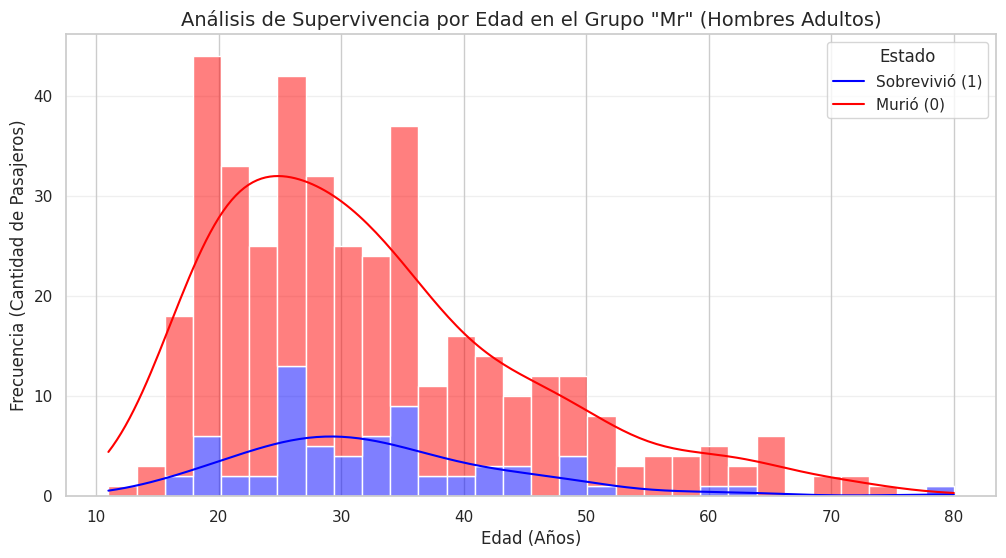

In [15]:
# 1. Filtrar solo los datos del grupo 'Mr'
mr_data = train[train['Title'] == 'Mr'].copy()

# 2. Configurar el Gráfico
plt.figure(figsize=(12, 6))

# Usamos Histplot para ver la frecuencia (cantidad de personas)
# multiple='stack' pone una barra sobre la otra
# bins=30 divide la edad en rangos pequeños para ver mejor el detalle
sns.histplot(
    data=mr_data, 
    x='Age', 
    hue='Survived', 
    multiple='stack', 
    palette={0: 'red', 1: 'blue'}, # Rojo para muerte (0), Azul para vida (1)
    bins=30,
    kde=True # Agregamos la línea de densidad para ver la forma de la curva
)

# 3. Etiquetas y Títulos
plt.title('Análisis de Supervivencia por Edad en el Grupo "Mr" (Hombres Adultos)', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Pasajeros)', fontsize=12)
plt.legend(title='Estado', labels=['Sobrevivió (1)', 'Murió (0)'])
plt.grid(axis='y', alpha=0.3)

plt.show()

#### Analisis de sobrevivencia para Master

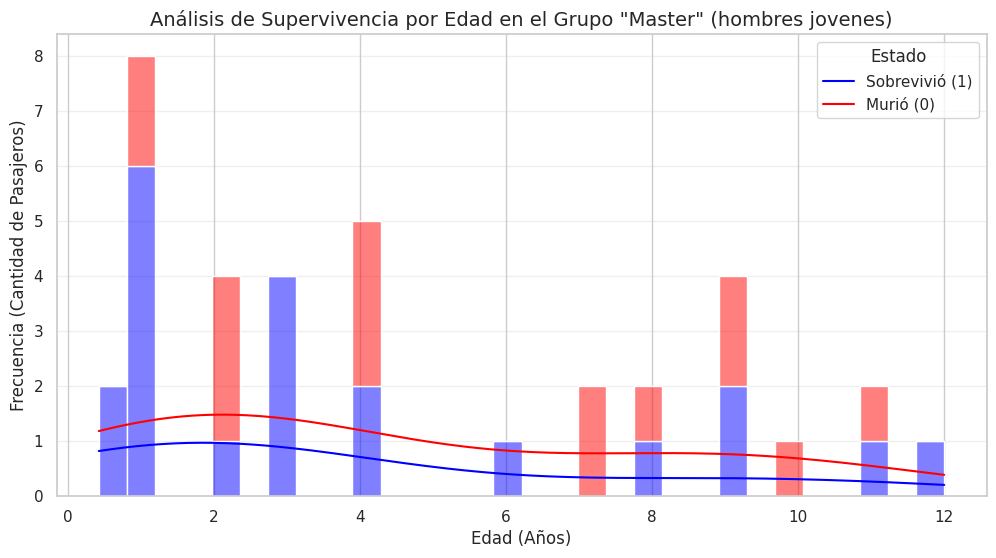

In [16]:
# 1. Filtrar solo los datos del grupo 'Mr'
mr_data = train[train['Title'] == 'Master'].copy()

# 2. Configurar el Gráfico
plt.figure(figsize=(12, 6))

# Usamos Histplot para ver la frecuencia (cantidad de personas)
# multiple='stack' pone una barra sobre la otra
# bins=30 divide la edad en rangos pequeños para ver mejor el detalle
sns.histplot(
    data=mr_data, 
    x='Age', 
    hue='Survived', 
    multiple='stack', 
    palette={0: 'red', 1: 'blue'}, # Rojo para muerte (0), Azul para vida (1)
    bins=30,
    kde=True # Agregamos la línea de densidad para ver la forma de la curva
)

# 3. Etiquetas y Títulos
plt.title('Análisis de Supervivencia por Edad en el Grupo "Master" (hombres jovenes)', fontsize=14)
plt.xlabel('Edad (Años)', fontsize=12)
plt.ylabel('Frecuencia (Cantidad de Pasajeros)', fontsize=12)
plt.legend(title='Estado', labels=['Sobrevivió (1)', 'Murió (0)'])
plt.grid(axis='y', alpha=0.3)

plt.show()

#### Prueba U Mann-Whitney no parametrica para evaluar diferencias en Master

Usaremos la Prueba U de Mann-Whitney (no paramétrica).
- $H_0$ (Hipótesis Nula): La distribución de edad es IGUAL para los niños que viven y los que mueren. (O sea, tener 2 años vs 9 años no cambiaba tu suerte, solo importaba ser "Master").
- $H_1$ (Hipótesis Alternativa): Hay una diferencia en la edad entre los grupos (ej. se salvaron más los bebés que los niños de 10 años).

In [17]:
# 1. Filtrar solo a los niños (Master)
master_data = train[train['Title'] == 'Master']

# 2. Separar las edades de los que vivieron y murieron
# Eliminamos NaNs para que la prueba no falle
age_survived = master_data[master_data['Survived'] == 1]['Age'].dropna()
age_died = master_data[master_data['Survived'] == 0]['Age'].dropna()

print(f"Cantidad de niños observados: {len(age_survived)} vivos vs {len(age_died)} muertos")
print(f"Edad promedio vivos: {age_survived.mean():.2f} años")
print(f"Edad promedio muertos: {age_died.mean():.2f} años")

# 3. Prueba de Normalidad (Shapiro-Wilk) para estar seguros
# Si p < 0.05, NO es normal -> Usamos Mann-Whitney obligatoriamente
shapiro_surv = stats.shapiro(age_survived)
shapiro_died = stats.shapiro(age_died)

# 4. Prueba U de Mann-Whitney (Comparación de Distribuciones)
stat, p_value = stats.mannwhitneyu(age_survived, age_died, alternative='two-sided')

print(f"\n--- Resultado Mann-Whitney U ---")
print(f"Estadístico U: {stat}")
print(f"P-Value: {p_value:.4f}")

# 5. Interpretación Automática
alpha = 0.05
if p_value < alpha:
    print("✅ RECHAZAMOS H0: La edad SÍ importó dentro de los niños.")
    print("   (Uno de los grupos era significativamente más joven/viejo que el otro).")
else:
    print("❌ NO podemos rechazar H0: Las distribuciones son iguales.")
    print("   Conclusión: Dentro del grupo 'Master', la edad exacta NO fue determinante.")
    print("   (La etiqueta 'Master' por sí sola es el predictor fuerte, no la edad numérica).")

Cantidad de niños observados: 21 vivos vs 15 muertos
Edad promedio vivos: 3.98 años
Edad promedio muertos: 5.40 años

--- Resultado Mann-Whitney U ---
Estadístico U: 111.5
P-Value: 0.1424
❌ NO podemos rechazar H0: Las distribuciones son iguales.
   Conclusión: Dentro del grupo 'Master', la edad exacta NO fue determinante.
   (La etiqueta 'Master' por sí sola es el predictor fuerte, no la edad numérica).


#### Prueba U Mann-Whitney no parametrica para evaluar diferencias en Mr

Usaremos la Prueba U de Mann-Whitney (no paramétrica).
- $H_0$ (Hipótesis Nula): La distribución de edad es IGUAL para los hombres que viven y los que mueren.
- $H_1$ (Hipótesis Alternativa): Hay una diferencia en la edad entre los grupos.

In [18]:
# 1. Filtrar solo a los niños (Master)
# Asegúrate de usar 'train' que es tu dataset principal
mr_data = train[train['Title'] == 'Mr']

# 2. Separar las edades de los que vivieron y murieron
# Eliminamos NaNs para que la prueba no falle
age_survived = mr_data[mr_data['Survived'] == 1]['Age'].dropna()
age_died = mr_data[mr_data['Survived'] == 0]['Age'].dropna()

print(f"Cantidad de 'Mr' observados con edad: {len(age_survived)} vivos vs {len(age_died)} muertos")

# Verificamos que haya datos suficientes en ambos grupos
if len(age_survived) > 0 and len(age_died) > 0:
    print(f"Edad promedio vivos: {age_survived.mean():.2f} años")
    print(f"Edad promedio muertos: {age_died.mean():.2f} años")

    # 3. Prueba de Normalidad (Shapiro-Wilk)
    # (Opcional, pero buena práctica)
    # Nota: Si hay pocos datos (<3), Shapiro puede lanzar warning, pero seguimos con Mann-Whitney
    if len(age_survived) >= 3 and len(age_died) >= 3:
        shapiro_surv = stats.shapiro(age_survived)
        shapiro_died = stats.shapiro(age_died)

    # 4. Prueba U de Mann-Whitney (Comparación de Distribuciones)
    # Usamos esta porque son pocos datos y probablemente no normales
    stat, p_value = stats.mannwhitneyu(age_survived, age_died, alternative='two-sided')

    print(f"\n--- Resultado Mann-Whitney U ---")
    print(f"Estadístico U: {stat}")
    print(f"P-Value: {p_value:.4f}")

    # 5. Interpretación Automática
    alpha = 0.05
    if p_value < alpha:
        print("✅ RECHAZAMOS H0: La edad SÍ importó dentro de los niños (Mr).")
        print("   (Uno de los grupos era significativamente más joven/viejo que el otro).")
    else:
        print("❌ NO podemos rechazar H0: Las distribuciones de edad son iguales.")
        print("   Conclusión: Dentro del grupo 'Mr', la edad exacta NO fue determinante.")
        print("   (La etiqueta 'Mr' es lo que importa, no si tenía 2 o 9 años).")

else:
    print("⚠️ No hay suficientes datos de edad (sin nulos) en uno de los grupos para hacer la prueba.")

Cantidad de 'Mr' observados con edad: 67 vivos vs 331 muertos
Edad promedio vivos: 33.04 años
Edad promedio muertos: 32.23 años

--- Resultado Mann-Whitney U ---
Estadístico U: 12025.5
P-Value: 0.2752
❌ NO podemos rechazar H0: Las distribuciones de edad son iguales.
   Conclusión: Dentro del grupo 'Mr', la edad exacta NO fue determinante.
   (La etiqueta 'Mr' es lo que importa, no si tenía 2 o 9 años).


#### Conclusion 

A partir de los resutlados obtenidos como la edad es irrelevante dentro del título, podemos rellenar los valores faltantes (NaN) de edad usando la Mediana del Título. Esto no introducirá sesgo (bias) en el modelo, porque la distribución es homogénea.

### Efecto de la profesion en Hombre

**Hipótesis para la Prueba: Efecto de la Profesión en Hombres (``Mr`` vs ``Officer``)**

- $H_0$ (*Hipótesis Nula*):El estatus profesional u oficial (``Officer``) no tiene efecto sobre la probabilidad de supervivencia en comparación con el estatus de hombre común (``Mr``). Estadísticamente, la tasa de supervivencia de ambos grupos es equivalente; cualquier diferencia observada es producto del azar.

- $H_1$ (*Hipótesis Alternativa*):Existe una diferencia estadísticamente significativa en la supervivencia entre los hombres comunes (``Mr``) y los profesionales/oficiales (``Officer``). La profesión influyó (ya sea positiva o negativamente) en su destino.

- Si **P-Value < 0.05** $\rightarrow$ Aceptamos $H_1$: Mantenemos los grupos separados (aportan información distinta).

- Si **P-Value > 0.05** $\rightarrow$ Mantenemos $H_0$: Los grupos se comportan igual. **Estrategia sugerida**: Podríamos fusionar ``Officer`` dentro de ``Mr`` para reducir la complejidad del modelo (evitar "ruido").

#### Analisis de sobrevivencia entre Mr y Officer

In [19]:
# Filtrar hombres que sean 'Mr' u 'Officer'
# Esto deja fuera a cualquier mujer que pudiera haber sido doctora (Dr)
subset_men = train[
    (train['Title'].isin(['Mr', 'Officer'])) & 
    (train['Sex'] == 'male')
].copy()

# 2. Tabla de Contingencia
contingency_men = pd.crosstab(subset_men['Title'], subset_men['Survived'])

print("\n--- Tabla de Contingencia ---")
display(contingency_men)

# 3. Porcentajes (Para ver la diferencia real)
print("\n--- Tasa de Supervivencia ---")
rates = pd.crosstab(subset_men['Title'], subset_men['Survived'], normalize='index') * 100
print(rates)

# 4. Prueba Chi-Cuadrado
chi2, p_value, dof, expected = stats.chi2_contingency(contingency_men)

print(f"\n--- Resultado Estadístico ---")
print(f"P-Value: {p_value:.4f}")

# 5. Interpretación
alpha = 0.05
if p_value < alpha:
    print("✅ RECHAZAMOS H0: Hay diferencia significativa.")
    print("   El estatus de 'Officer/Profesional' afectó la supervivencia comparado con 'Mr'.")
    print("   (Mira los porcentajes para ver quién sobrevivió más).")
else:
    print("❌ NO podemos rechazar H0: Estadísticamente son iguales.")
    print("   Un Oficial murió con la misma probabilidad que un hombre común.")
    print("   (Podríamos considerar fusionarlos si simplificamos el modelo).")


--- Tabla de Contingencia ---


Survived,0,1
Title,,
Mr,436,81
Officer,13,4



--- Tasa de Supervivencia ---
Survived          0          1
Title                         
Mr        84.332689  15.667311
Officer   76.470588  23.529412

--- Resultado Estadístico ---
P-Value: 0.5927
❌ NO podemos rechazar H0: Estadísticamente son iguales.
   Un Oficial murió con la misma probabilidad que un hombre común.
   (Podríamos considerar fusionarlos si simplificamos el modelo).


En el contexto de la epoca la matyoria de los cargos `Officer` eran hombres, pero se evaluara si es verdad. 

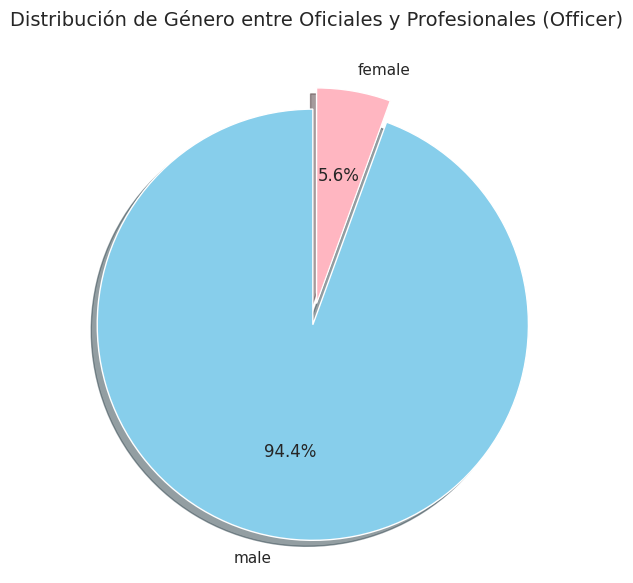

Total: 18 Oficiales
Sex
male      17
female     1
Name: count, dtype: int64


In [20]:
officer_counts = train[train['Title'] == 'Officer']['Sex'].value_counts()

plt.figure(figsize=(7, 7))
plt.pie(
    officer_counts, 
    labels=officer_counts.index, 
    autopct='%1.1f%%',  # Muestra el porcentaje
    startangle=90, 
    colors=['skyblue', 'lightpink'], # Azul para hombres, Rosa para mujeres (convención visual rápida)
    explode=(0.1, 0) if len(officer_counts) > 1 else None, # Separa ligeramente la rebanada mayor si hay 2
    shadow=True
)

plt.title('Distribución de Género entre Oficiales y Profesionales (Officer)', fontsize=14)
plt.show()

print(f"Total: {officer_counts.sum()} Oficiales")
print(officer_counts)

Identificando si el outlier del grupo `Officer` de sexo esa ``female`` sobrevivio 

In [21]:
female_officer = train[(train['Title'] == 'Officer') & (train['Sex'] == 'female')]

print("--- La única mujer 'Officer' ---")
display(female_officer[['Name', 'Title', 'Age', 'Survived', 'Pclass']])

if female_officer['Survived'].iloc[0] == 1:
    print("\n✅ RESULTADO: Ella SOBREVIVIÓ.")
    print("   Esto confirma la regla: 'Las mujeres primero', incluso si tienen título profesional.")
else:
    print("\n❌ RESULTADO: Ella murió.")

--- La única mujer 'Officer' ---


,Name,Title,Age,Survived,Pclass
796,"Leader, Dr. Alice (Farnham)",Officer,49.0,1,1



✅ RESULTADO: Ella SOBREVIVIÓ.
   Esto confirma la regla: 'Las mujeres primero', incluso si tienen título profesional.


#### Conclusion

**1. Jerarquía Predictiva (Género > Profesión)**
El análisis detallado del grupo `Officer`, y específicamente del caso atípico de la única mujer presente (Dra. Alice Leader, quien sobrevivió), confirma que el **Género** actúa como una fuerza "gravitacional" superior al estatus profesional. Mientras que sus colegas varones (doctores y oficiales) perecieron, su condición de mujer fue el factor determinante para su rescate.

**2. Redundancia Estadística**
La prueba de Chir-Cuadrado demostro que el grupo **Officer (Masculino)** es estadísticamente indistinguible del grupo **Mr** en términos de supervivencia. Ambos enfrentan la misma alta probabilidad de mortalidad, lo que indica que mantener una categoría separada para "Oficiales" no aporta valor predictivo marginal al modelo; es simplemente "ruido".

**3. Estrategia Final: Simplificación del Modelo**
Basado en esta evidencia, se procedera a eliminar la categoría `Officer` para reducir la complejidad del modelo, reintegrando estos registros a los grupos demográficos principales:

* **Officer (Hombres)  `Mr`:** Se fusionarán con el grupo estándar de hombres adultos.
* **Officer (Mujer)  `Mrs`:** Se reasignará al grupo de mujeres casadas (asumiendo estatus adulto).

### Fusion Officer a Mr y Mrs


1. Edad de la 'Officer' (Dr. Alice Leader): 49.0 años

2. Estadísticas de Edad del grupo 'Mrs':
count    109.000000
mean      35.788991
min       14.000000
25%       27.000000
50%       35.000000
75%       44.000000
max       63.000000
Name: Age, dtype: float64


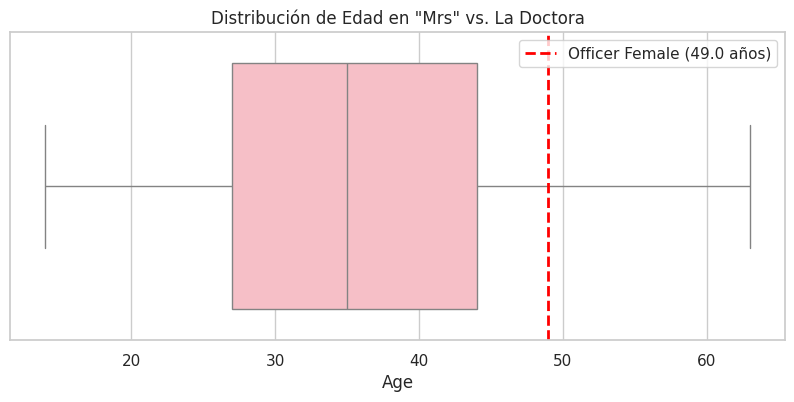


--- VEREDICTO ---
✅ APROBADO: La edad de la Doctora está dentro del rango normal de 'Mrs'.
   Es estadísticamente seguro fusionarla.


In [22]:
# Datos de la Doctora (Officer Female)
doctor_female = train[(train['Title'] == 'Officer') & (train['Sex'] == 'female')]
doc_age = doctor_female['Age'].values[0]

print(f"\n1. Edad de la 'Officer' (Dr. Alice Leader): {doc_age} años")

mrs_stats = train[train['Title'] == 'Mrs']['Age'].describe()

print("\n2. Estadísticas de Edad del grupo 'Mrs':")
print(mrs_stats[['count', 'mean', 'min', '25%', '50%', '75%', 'max']])

# 3. Validación Visual (Boxplot)
plt.figure(figsize=(10, 4))
sns.boxplot(x=train[train['Title'] == 'Mrs']['Age'], color='lightpink')

# línea roja donde está la Doctora
plt.axvline(doc_age, color='red', linestyle='--', linewidth=2, label=f'Officer Female ({doc_age} años)')
plt.title('Distribución de Edad en "Mrs" vs. La Doctora')
plt.legend()
plt.show()

# 4. Veredicto Automático
q1 = mrs_stats['25%']
q3 = mrs_stats['75%']
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

print("\n--- VEREDICTO ---")
if lower_bound <= doc_age <= upper_bound:
    print("✅ APROBADO: La edad de la Doctora está dentro del rango normal de 'Mrs'.")
    print("   Es estadísticamente seguro fusionarla.")
else:
    print("⚠️ ATENCIÓN: Podría ser un Outlier (valor atípico).")
    print("   (Aunque si es adulta, sigue encajando mejor en Mrs que en Miss).")

In [24]:
# Fusión Específica: Mujer Officer -> Mrs
# Buscar filas donde Title sea 'Officer' Y Sex sea 'female'
mask_female_officer = (train['Title'] == 'Officer') & (train['Sex'] == 'female')
train.loc[mask_female_officer, 'Title'] = 'Mrs'

print(f" -> Se han reasignado {mask_female_officer.sum()} mujer(es) de 'Officer' a 'Mrs'.")

# Fusión General: Hombres Officer -> Mr
# Buscar filas donde Title sea 'Officer' (Los que quedan son todos hombres)
mask_male_officer = (train['Title'] == 'Officer')
train.loc[mask_male_officer, 'Title'] = 'Mr'

print(f" -> Se han reasignado {mask_male_officer.sum()} hombres de 'Officer' a 'Mr'.")

# Auditoría Final de la Variable
print("\n--- Distribución Final de Títulos (Lista para el Modelo) ---")
print(train['Title'].value_counts())

# Validación rápida
print("\n--- Verificación de Supervivencia por Nuevos Grupos ---")
print(pd.crosstab(train['Title'], train['Survived'], normalize='index') * 100)

 -> Se han reasignado 0 mujer(es) de 'Officer' a 'Mrs'.
 -> Se han reasignado 0 hombres de 'Officer' a 'Mr'.

--- Distribución Final de Títulos (Lista para el Modelo) ---
Title
Mr          534
Miss        185
Mrs         127
Master       40
Nobility      5
Name: count, dtype: int64

--- Verificación de Supervivencia por Nuevos Grupos ---
Survived          0          1
Title                         
Master    42.500000  57.500000
Miss      29.729730  70.270270
Mr        84.082397  15.917603
Mrs       20.472441  79.527559
Nobility  40.000000  60.000000


### Efecto del titulo nobiliario y comparacion con sexo y edad con el resto de los pasajeros

In [25]:
# Calcular los estadísticos descriptivos agrupados
# Incluimos: count (cantidad de datos reales), min, max y median
age_summary = train.groupby('Title')['Age'].agg(['min', 'max', 'median', 'mean', 'count'])

# Ordenar para facilitar la lectura (por ejemplo, por edad mínima)
age_summary = age_summary.sort_values(by='median')

# Formato visual
print("\n--- Rango de Edad (Mínimo - Máximo) y Mediana ---")
display(age_summary)


--- Rango de Edad (Mínimo - Máximo) y Mediana ---


,min,max,median,mean,count
Title,,,,,
Master,0.42,12.0,3.5,4.574167,36
Miss,0.75,63.0,21.0,21.845638,149
Mr,11.00,80.0,30.0,32.916667,414
Mrs,14.00,63.0,35.0,35.909091,110
Nobility,33.00,49.0,40.0,41.600000,5


#### Comparacion entre grupos `Nobility`, `Mrs`, `Mr` y `Miss` que tengan la misma edad y sexo

#### Prueba de Fisher

In [26]:
# Definir el rango estricto de la Nobleza
min_age, max_age = 33, 49
print(f"Rango de control: {min_age} a {max_age} años\n")

# Función auxiliar para el reporte
def compare_subsets(group_noble, group_common, label_noble, label_common):
    # 1. Filtrar por edad
    subset_noble = group_noble[(group_noble['Age'] >= min_age) & (group_noble['Age'] <= max_age)]
    subset_common = group_common[(group_common['Age'] >= min_age) & (group_common['Age'] <= max_age)]
    
    # 2. Obtener conteos de sobrevivientes
    # Estructura: [[Noble_Vivos, Noble_Muertos], [Comun_Vivos, Comun_Muertos]]
    surv_noble = subset_noble['Survived'].sum()
    dead_noble = len(subset_noble) - surv_noble
    
    surv_common = subset_common['Survived'].sum()
    dead_common = len(subset_common) - surv_common
    
    # 3. Tasas
    rate_noble = (surv_noble / len(subset_noble) * 100) if len(subset_noble) > 0 else 0
    rate_common = (surv_common / len(subset_common) * 100) if len(subset_common) > 0 else 0
    
    print(f"--- Comparación: {label_noble} vs {label_common} ---")
    print(f"{label_noble}: {surv_noble} vivos / {len(subset_noble)} total ({rate_noble:.1f}%)")
    print(f"{label_common}:   {surv_common} vivos / {len(subset_common)} total ({rate_common:.1f}%)")
    
    # 4. Prueba Exacta de Fisher
    contingency = [[surv_noble, dead_noble], [surv_common, dead_common]]
    oddsr, p_value = stats.fisher_exact(contingency)
    
    print(f"P-Value (Fisher): {p_value:.4f}")
    
    if p_value < 0.05:
        print("✅ DIFERENCIA SIGNIFICATIVA: El título Noble SÍ importó más que la edad.")
    else:
        print("❌ NO Significativo: Estadísticamente igual (quizás por falta de datos).")
    print("-" * 30 + "\n")

# --- EJECUCIÓN ---

# 1. Comparación HOMBRES: Nobleza vs Mr
men_noble = train[(train['Title'] == 'Nobility') & (train['Sex'] == 'male')]
men_mr = train[(train['Title'] == 'Mr')]
compare_subsets(men_noble, men_mr, "Nobles (Hombres)", "Mr (Hombres)")

# 2. Comparación MUJERES: Nobleza vs Mrs/Miss
women_noble = train[(train['Title'] == 'Nobility') & (train['Sex'] == 'female')]
women_common = train[train['Title'].isin(['Mrs', 'Miss'])]
compare_subsets(women_noble, women_common, "Nobles (Mujeres)", "Mrs/Miss")

Rango de control: 33 a 49 años

--- Comparación: Nobles (Hombres) vs Mr (Hombres) ---
Nobles (Hombres): 1 vivos / 3 total (33.3%)
Mr (Hombres):   23 vivos / 120 total (19.2%)
P-Value (Fisher): 0.4817
❌ NO Significativo: Estadísticamente igual (quizás por falta de datos).
------------------------------

--- Comparación: Nobles (Mujeres) vs Mrs/Miss ---
Nobles (Mujeres): 2 vivos / 2 total (100.0%)
Mrs/Miss:   53 vivos / 67 total (79.1%)
P-Value (Fisher): 1.0000
❌ NO Significativo: Estadísticamente igual (quizás por falta de datos).
------------------------------



#### **Conclusión y Estrategia de Fusión para "Nobility":**

Tras aplicar la Prueba Exacta de Fisher controlando por rangos de edad, los resultados (P-Value > 0.05) demostraron que poseer un título nobiliario no otorgó una ventaja de supervivencia estadísticamente significativa frente a los pasajeros comunes del mismo género. Dado que los hombres nobles mostraron tasas de mortalidad similares a los `Mr`, y las mujeres nobles tasas de supervivencia análogas a las `Mrs`, y considerando el riesgo de *overfitting* al mantener una categoría con solo 5 registros, procederemos a simplificar el modelo: los títulos aristocráticos masculinos (*Sir, Don, Jonkheer*) se integrarán en **`Mr`** y los femeninos (*Countess, Lady, Dona*) en **`Mrs`**, dejando una variable `Title` final con cuatro categorías demográficas robustas.

In [27]:
# 1. Fusión: Nobleza Masculina -> Mr
# (Don, Sir, Jonkheer) pasan a ser Mr
mask_male_noble = (train['Title'] == 'Nobility') & (train['Sex'] == 'male')
train.loc[mask_male_noble, 'Title'] = 'Mr'

print(f" -> Se han reasignado {mask_male_noble.sum()} hombres de 'Nobility' a 'Mr'.")

# 2. Fusión: Nobleza Femenina -> Mrs
# (Countess, Lady, Dona) pasan a ser Mrs (Mujeres adultas tituladas)
mask_female_noble = (train['Title'] == 'Nobility') & (train['Sex'] == 'female')
train.loc[mask_female_noble, 'Title'] = 'Mrs'

print(f" -> Se han reasignado {mask_female_noble.sum()} mujeres de 'Nobility' a 'Mrs'.")

# 3. Auditoría Final de la Variable TITLE
print("\n--- ✅ DISTRIBUCIÓN DEFINITIVA DE TÍTULOS ---")
print(train['Title'].value_counts())

# 4. Verificación de Integridad
print("\n--- Verificación de Nulos o Errores ---")
print(f"Nulos en Title: {train['Title'].isnull().sum()}")

 -> Se han reasignado 3 hombres de 'Nobility' a 'Mr'.
 -> Se han reasignado 2 mujeres de 'Nobility' a 'Mrs'.

--- ✅ DISTRIBUCIÓN DEFINITIVA DE TÍTULOS ---
Title
Mr        537
Miss      185
Mrs       129
Master     40
Name: count, dtype: int64

--- Verificación de Nulos o Errores ---
Nulos en Title: 0


### 

In [29]:
print("## Comparación Sociológica: Mujeres Casadas (Mrs) vs Solteras Adultas (Miss)")
print("   (Rango de Control: 14 a 63 años)")

# 1. Filtro Quirúrgico
# - Solo Mujeres
# - Edad entre 14 y 63 (inclusive)
# - Solo Títulos 'Mrs' y 'Miss'
subset_women = train[
    (train['Sex'] == 'female') &
    (train['Age'] >= 14) & 
    (train['Age'] <= 63) &
    (train['Title'].isin(['Mrs', 'Miss']))
].copy()

# 2. Tabla de Contingencia
contingency = pd.crosstab(subset_women['Title'], subset_women['Survived'])

print("\n--- Tabla de Contingencia (Vivas vs Muertas) ---")
display(contingency)

# 3. Tasas de Supervivencia
rates = pd.crosstab(subset_women['Title'], subset_women['Survived'], normalize='index') * 100
print("\n--- Tasas de Supervivencia (%) ---")
print(rates)

# 4. Prueba Chi-Cuadrado de Independencia
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\n--- Resultado Estadístico ---")
print(f"P-Value: {p_value:.4f}")

# 5. Interpretación
alpha = 0.05
if p_value < alpha:
    print("✅ DIFERENCIA SIGNIFICATIVA: El estado civil importó.")
    if rates.loc['Mrs', 1] > rates.loc['Miss', 1]:
        print("   Las esposas (Mrs) tuvieron prioridad sobre las solteras (Miss).")
    else:
        print("   Las solteras (Miss) tuvieron prioridad.")
else:
    print("❌ NO Significativo: 'Mujeres son mujeres'.")
    print("   El protocolo de rescate no distinguió entre casadas y solteras en este rango de edad.")
    print("   (Se pueden tratar como un solo grupo 'Women' si se desea).")

## Comparación Sociológica: Mujeres Casadas (Mrs) vs Solteras Adultas (Miss)
   (Rango de Control: 14 a 63 años)

--- Tabla de Contingencia (Vivas vs Muertas) ---


Survived,0,1
Title,,
Miss,28,87
Mrs,23,89



--- Tasas de Supervivencia (%) ---
Survived          0          1
Title                         
Miss      24.347826  75.652174
Mrs       20.535714  79.464286

--- Resultado Estadístico ---
P-Value: 0.5968
❌ NO Significativo: 'Mujeres son mujeres'.
   El protocolo de rescate no distinguió entre casadas y solteras en este rango de edad.
   (Se pueden tratar como un solo grupo 'Women' si se desea).


In [30]:
import pandas as pd
import scipy.stats as stats

print("## Comparación Demográfica: Niñas (<14) vs Mujeres Adultas (>=14)")

# 1. Filtro: Solo mujeres con Edad conocida (Importante porque no hemos imputado todo aún)
female_subset = train[
    (train['Sex'] == 'female') & 
    (train['Age'].notnull())
].copy()

# 2. Creación de Categoría Temporal
# Usamos el corte de 14 años que solicitaste
female_subset['AgeGroup'] = female_subset['Age'].apply(lambda x: 'Niña (<14)' if x < 14 else 'Mujer (>=14)')

# 3. Tabla de Contingencia
contingency = pd.crosstab(female_subset['AgeGroup'], female_subset['Survived'])

print("\n--- Tabla de Contingencia ---")
display(contingency)

# 4. Tasas de Supervivencia
rates = pd.crosstab(female_subset['AgeGroup'], female_subset['Survived'], normalize='index') * 100
print("\n--- Tasa de Supervivencia (%) ---")
print(rates)

# 5. Prueba Chi-Cuadrado
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

print(f"\n--- Resultado Estadístico ---")
print(f"P-Value: {p_value:.4f}")

# 6. Interpretación Automática
alpha = 0.05
if p_value < alpha:
    print("✅ DIFERENCIA SIGNIFICATIVA: La edad importó entre las mujeres.")
    if rates.loc['Niña (<14)', 1] > rates.loc['Mujer (>=14)', 1]:
        print("   Las niñas tuvieron prioridad sobre las adultas.")
    else:
        print("   CURIOSO: Las mujeres adultas sobrevivieron más que las niñas.")
        print("   (Posible explicación: Las niñas de 3ra clase en familias grandes murieron más).")
else:
    print("❌ NO Significativo: La edad no importó.")
    print("   Ser mujer fue el salvoconducto principal, sin importar si eras niña o adulta.")

## Comparación Demográfica: Niñas (<14) vs Mujeres Adultas (>=14)

--- Tabla de Contingencia ---


Survived,0,1
AgeGroup,,
Mujer (>=14),51,176
Niña (<14),13,21



--- Tasa de Supervivencia (%) ---
Survived              0          1
AgeGroup                          
Mujer (>=14)  22.466960  77.533040
Niña (<14)    38.235294  61.764706

--- Resultado Estadístico ---
P-Value: 0.0752
❌ NO Significativo: La edad no importó.
   Ser mujer fue el salvoconducto principal, sin importar si eras niña o adulta.
